<a href="https://colab.research.google.com/github/ljm0616/Capstone_project/blob/main/%EB%B0%98%EB%8F%84%EC%B2%B4_%EA%B3%B5%EC%A0%95%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D%EC%8B%A4%EC%8A%B5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 반도체 공정 데이터 분석 — 불량 신호 탐색과 룰베이스 분류

## 파일 사용법

이 노트북은 ChatGPT가 코드를 **작성하고 직접 실행**한 뒤, 같은 코드를 Colab에서도 실행해 결과를 확인하는 방식으로 사용한다.

1. 새 ChatGPT 대화를 열고 `반도체_공정데이터_전체.csv`와 `koreanize_matplotlib-0.1.1-py3-none-any.whl`을 함께 첨부한다.
2. 아래의 **새 ChatGPT 대화 시작 프롬프트**를 한 번 입력한다.
3. 각 과제의 첫 번째 프롬프트를 입력한다.
4. ChatGPT가 제시하고 직접 실행한 코드를 해당 Colab 코드 셀에 복사해 실행한 뒤 두 결과를 비교한다.
5. 같은 ChatGPT 대화에서 해당 과제의 다음 프롬프트를 입력한다.
6. ChatGPT가 작성한 해석을 해당 과제의 Colab 마크다운 셀에 복사해 넣는다.

ChatGPT가 같은 대화에서 직접 만든 표와 그래프를 보고 있으므로, Colab 결과가 동일하다면 화면을 다시 첨부하지 않는다. 코드를 수정했거나 두 환경의 결과가 다를 때만 Colab 화면을 첨부한다.

## 그래프 한글 표기

- **ChatGPT:** 함께 첨부한 wheel 파일을 대화의 Python 환경에 설치한다.
- **Colab:** 환경 준비 셀에서 PyPI의 `koreanize-matplotlib`을 설치한다.
- 두 환경 모두 이후 분석·시각화 코드에서 한글 제목과 축 이름을 사용한다.

## 분석 시나리오

반도체 생산 공정에서 수집한 웨이퍼별 공정 지표와 최종 검사 결과를 분석한다. 어떤 공정 변수에서 `Pass`와 `Fail`의 분포 차이가 나타나는지 찾고, 이해하기 쉬운 세 가지 룰을 단계적으로 결합하여 불량 웨이퍼를 어느 정도 선별할 수 있는지 확인한다.

학생 실습은 데이터 파악, 시각화 탐색, 핵심 변수 심화 분석, 인사이트 정리, 룰 도출 및 검증 순으로 진행한다. 이 실습에서 양성 클래스는 **Fail**이며, Precision과 Recall도 Fail을 기준으로 계산한다.

- 파일: `반도체_공정데이터_전체.csv` (728행, 32개 컬럼)
- 식별자: `wafer_id`
- 타겟: `inspection_result` (`Pass` / `Fail`)
- 입력 변수: 30개의 수치형 공정 지표

> **주의:** 변수명은 공정 단계와 측정 항목을 나타내지만 물리 단위는 별도로 제공되지 않았다. 값의 절대적인 공학적 의미를 추정하지 않고, 이 데이터 안에서 나타나는 상대적 분포와 분류 신호를 중심으로 해석한다.


## 새 ChatGPT 대화 시작 프롬프트

`반도체_공정데이터_전체.csv`와 `koreanize_matplotlib-0.1.1-py3-none-any.whl`을 함께 첨부한 새 대화에서 아래 내용을 처음부터 끝까지 한 번 입력한다. 프롬프트 본문은 복사하기 쉽도록 코드 블록으로 감싸지 않았다.

첨부한 `반도체_공정데이터_전체.csv`로 Python 데이터 분석 실습을 진행하겠습니다. 한글 그래프를 위해 함께 첨부한 `koreanize_matplotlib-0.1.1-py3-none-any.whl`을 사용하세요. 앞으로 분석 작업을 하나씩 요청할 테니 다음 기준을 계속 지켜 주세요.

- 요청한 작업만 수행하고 이후 분석을 미리 진행하지 마세요.
- 코드 작성을 요청하면 Colab 코드 셀에 바로 붙여 넣을 수 있는 해당 과제의 전체 Python 코드를 먼저 제시한 다음, 같은 코드를 ChatGPT의 데이터 분석 환경에서 직접 실행하여 지정한 결과를 보여 주세요.
- 코드 실행 단계에서는 결과를 해석하거나 다음 분석을 진행하지 마세요.
- 결과 해석을 요청하면 해당 과제에서 이 대화로 직접 실행해 확인한 결과만 근거로 사용하세요.
- 결과 해석 단계에서는 새로운 계산이나 그래프 작성, 다음 단계 분석을 진행하지 마세요.
- 해석은 Colab 마크다운 셀에 그대로 붙여 넣을 수 있는 일반 마크다운 본문으로 작성하고 마크다운 코드 블록으로 감싸지 마세요.
- 지정한 출력이나 해석을 완료하면 추가 작업을 제안하지 말고 멈춰서 다음 요청을 기다리세요.
- 앞선 요청에서 만든 `df`, `불량값`, `signal_cols`, `rule1` 등의 변수와 분석 환경은 같은 대화에서 계속 사용하세요.
- 초보자가 이해하기 쉬운 일반적인 코드를 사용하고 지나치게 압축하거나 복잡한 방법은 피하세요.
- 데이터를 변경하라는 요청이 없다면 원본 데이터프레임을 임의로 수정하지 마세요.
- 그래프의 제목·축·범례는 한글로 작성하세요.
- `inspection_result`에서 `Fail`을 양성 클래스 1, `Pass`를 음성 클래스 0으로 사용하세요.

먼저 다음 초기화 코드를 그대로 직접 실행하세요. 분석은 시작하지 말고, 실행이 끝나면 `한글 그래프 설정 완료`와 `준비되었습니다.`만 출력한 뒤 멈추세요.

```python
import sys
import subprocess
from pathlib import Path

search_roots = [Path('/mnt/data'), Path.cwd()]
wheel_files = []
for root in search_roots:
    if root.exists():
        wheel_files.extend(root.rglob('koreanize_matplotlib-*.whl'))

if not wheel_files:
    raise FileNotFoundError(
        '첨부한 koreanize_matplotlib wheel 파일을 찾을 수 없습니다.'
    )

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', str(wheel_files[0])],
    check=True
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

sns.set_theme(style='whitegrid')
koreanize_matplotlib.koreanize()
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
print('한글 그래프 설정 완료')
print('준비되었습니다.')
```


## 0. Colab 환경 준비

아래 두 코드 셀을 순서대로 실행한다. 첫 번째 셀은 `koreanize-matplotlib`을 설치하고, 두 번째 셀은 분석 라이브러리와 한글 그래프 설정을 불러온다. 런타임을 새로 시작한 경우 두 셀을 다시 실행한다.


In [ ]:
import sys
import subprocess

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'koreanize-matplotlib'],
    check=True
)
print('koreanize-matplotlib 설치 완료')


koreanize-matplotlib 설치 완료


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from pathlib import Path

sns.set_theme(style='whitegrid')
koreanize_matplotlib.koreanize()
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
print('한글 그래프 설정 완료')


한글 그래프 설정 완료


---
## 1. 데이터 파악


### 과제 1-1. 데이터를 불러오고 모양과 처음 5행을 확인하시오.


**Prompt**

첨부한 `반도체_공정데이터_전체.csv`를 판다스로 불러와 `df`에 저장하고, 사용한 파일명과 데이터 크기, 처음 5행을 확인하는 코드를 작성해 주세요. 파일명 뒤에 `(1)` 같은 숫자가 붙어 있어도 찾을 수 있게 해 주세요.


In [ ]:
search_roots = [Path('.'), Path('/content'), Path('/mnt/data')]
csv_files = []
for root in search_roots:
    if root.exists():
        csv_files.extend(root.rglob('반도체_공정데이터_전체*.csv'))

if not csv_files:
    raise FileNotFoundError('반도체 공정 데이터 CSV를 찾을 수 없습니다.')

data_path = sorted(set(csv_files), key=lambda p: len(p.name))[0]
df = pd.read_csv(data_path)

print('사용 파일:', data_path.name)
print('데이터 크기:', df.shape)
display(df.head())


사용 파일: 반도체_공정데이터_전체.csv
데이터 크기: (728, 32)


,wafer_id,etch_chamber_temp_avg,cmp_endpoint_thickness,thermal_anneal_temp_max,etch_endpoint_signal,wafer_edge_exclusion,etch_pressure_peak,cmp_pad_temp,deposition_uniformity_index,deposition_thickness_var,cleaning_dhf_concentration,deposition_rate_mean,implant_dose_total,litho_overlay_y,etch_chamber_temp_std,deposition_gas_flow_avg,litho_overlay_x,metrology_cd_mean,cmp_slurry_flow_rate,implant_beam_current,metrology_cd_uniformity,etch_rf_power_mean,cmp_polish_time,litho_exposure_time,deposition_chamber_pressure,litho_dose_avg,implant_tilt_angle,implant_energy_mean,cmp_pressure_avg,particle_count_post,litho_focus_offset,inspection_result
0,WH_0000,2.2300,17.7700,10.1066,66.4333,57.6641,-5333.75,11.3429,0.0492,NaN,1.8000,0.6304,15.74,6.34615,55.4572,3.5690,8.1584,0.0,1.4391,3.12,0.0192,-3.5430,4.1872,0.103,0.0755,0.0295,5.3530,1.7350,15.65,221.4286,-0.0085,Pass
1,WH_0001,0.8764,NaN,4.9259,69.3333,902.0772,0.00,0.0000,0.0000,8.7696,3.3099,0.7713,15.91,6.34615,60.1367,NaN,0.0000,NaN,0.0000,19.90,0.0254,1.9390,0.0000,0.000,0.1004,0.0295,6.5683,0.9791,15.93,52.4656,-0.0110,Pass
2,WH_0002,27.4627,12.5373,5.4171,72.8222,529.3532,-6312.25,7.6993,0.0460,9.3998,3.2042,0.6518,15.82,6.75350,NaN,21.9603,11.3706,0.0,1.8363,6.76,0.0533,NaN,4.3765,0.112,0.2177,0.0315,5.8049,1.3800,15.88,410.1695,-0.0100,Pass
3,WH_0003,-2.8555,22.8555,6.7199,NaN,0.0000,-6476.25,NaN,0.0344,NaN,2.0083,NaN,15.51,NaN,51.3761,5.6831,7.2993,0.0,6.7630,5.02,0.0279,-1.2770,2.8420,0.080,0.0956,0.0295,5.6773,1.1020,15.47,767.4074,-0.0109,Pass
4,WH_0004,-2.0836,22.0836,13.9342,NaN,229.3217,NaN,6.4235,0.0466,8.7568,3.8979,0.7611,15.90,2.64820,35.6627,8.4789,7.9365,0.0,1.1425,7.32,0.0182,0.4258,NaN,0.100,NaN,0.0123,NaN,0.9838,15.95,134.6375,-0.0104,Pass


**Prompt**

데이터의 크기, 한 행이 나타내는 대상, 식별자와 타겟 컬럼을 3문장 이내로 해석해 주세요.


**해석:**

데이터는 **728행, 32개 컬럼**으로 구성되어 있으며, 한 행은 웨이퍼 한 장의 공정 측정 기록을 나타냅니다. `wafer_id`는 웨이퍼를 구분하는 식별자이고, 30개의 수치형 공정 지표가 입력 변수로 들어 있습니다. 분석 대상인 `inspection_result`는 최종 검사 결과인 `Pass` 또는 `Fail`로 기록되어 있습니다.


### 과제 1-2. 각 컬럼의 자료형과 결측치를 확인하시오.


**Prompt**

현재 `df`의 각 컬럼명과 자료형, 결측치 수, 결측률을 하나의 표로 출력하는 판다스 코드를 작성해 주세요. 결측치가 많은 컬럼부터 정렬하고 결측률은 소수점 첫째 자리까지 표시해 주세요.


In [ ]:
missing_table = pd.DataFrame({
    '자료형': df.dtypes.astype(str),
    '결측치수': df.isna().sum(),
    '결측률(%)': df.isna().mean().mul(100).round(1)
}).sort_values('결측치수', ascending=False)

display(missing_table)
print('전체 결측치 수:', int(df.isna().sum().sum()))


,자료형,결측치수,결측률(%)
deposition_thickness_var,float64,71,9.8
thermal_anneal_temp_max,float64,69,9.5
metrology_cd_mean,float64,69,9.5
wafer_edge_exclusion,float64,68,9.3
deposition_gas_flow_avg,float64,67,9.2
litho_overlay_y,float64,66,9.1
implant_tilt_angle,float64,66,9.1
cleaning_dhf_concentration,float64,63,8.7
cmp_endpoint_thickness,float64,63,8.7
etch_endpoint_signal,float64,61,8.4


전체 결측치 수: 1617


**Prompt**

수치형·범주형 컬럼 구성을 구분하고, 결측치가 가장 많은 컬럼과 가장 적은 수치형 컬럼, 전체 결측치 수를 4문장 이내로 해석해 주세요.


**해석:**

`wafer_id`와 `inspection_result`는 문자열형이고 나머지 **30개 공정 변수는 모두 수치형**입니다. 결측치가 가장 많은 변수는 `deposition_thickness_var`로 **71개**이며, 수치형 변수 중 가장 적은 `litho_focus_offset`에도 37개가 있습니다. `wafer_id`와 `inspection_result`에는 결측치가 없습니다. 전체 결측치 수는 **1,617개**이므로 이후 계산과 시각화에서 결측치가 자동으로 제외되는지 확인해야 합니다.


### 과제 1-3. 수치형 변수의 기초 통계량을 확인하시오.


**Prompt**

현재 `df`에서 수치형 컬럼만 선택해 개수, 평균, 표준편차, 최솟값, 사분위수와 최댓값을 확인하는 코드를 작성해 주세요. 결과는 소수점 넷째 자리까지 표시해 주세요.


In [ ]:
numeric_summary = df.select_dtypes(include='number').describe().T.round(4)
display(numeric_summary)


,count,mean,std,min,25%,50%,75%,max
etch_chamber_temp_avg,688.0,5.1899,10.6183,-28.9882,-1.1652,1.6304,8.0178,66.4977
cmp_endpoint_thickness,665.0,20.5525,5.2989,6.4482,17.1755,19.8336,22.8727,48.9882
thermal_anneal_temp_max,659.0,12.1551,5.1467,3.5634,8.8333,11.3171,14.4194,65.1651
etch_endpoint_signal,667.0,69.0826,3.3262,59.4000,67.1778,68.9000,71.2056,77.3444
wafer_edge_exclusion,660.0,260.6591,325.1381,0.0000,0.0000,0.0000,530.9856,996.7213
etch_pressure_peak,679.0,-5613.9297,672.7374,-7150.2500,-6039.0000,-5527.0000,-5344.0000,0.0000
cmp_pad_temp,683.0,18.8781,38.3929,0.0000,7.1213,11.3232,17.3571,400.0000
deposition_uniformity_index,683.0,0.0647,0.0645,0.0000,0.0412,0.0536,0.0705,0.5255
deposition_thickness_var,657.0,8.9747,1.4346,8.0787,8.5862,8.7851,9.0744,23.3453
cleaning_dhf_concentration,665.0,3.9719,1.2973,0.7217,3.0957,3.8868,4.7460,12.5945


**Prompt**

기초 통계량에서 눈에 띄는 값의 범위, 중앙값과 최댓값의 차이, 이상치 가능성을 4문장 이내로 해석해 주세요. 아직 Fail의 원인이라고 단정하지 마세요.


**해석:**

`etch_chamber_temp_avg`는 -28.9882부터 66.4977까지 넓게 분포하고 `litho_focus_offset`은 -0.0170부터 0.0106까지 비교적 좁은 범위에 있습니다. `metrology_cd_mean`은 중앙값이 0이지만 최댓값은 1,000이며, 여러 CMP·증착·노광 변수에서도 최댓값 400이 나타납니다. 일부 변수는 평균이 중앙값보다 훨씬 커서 오른쪽 꼬리와 큰 값의 영향을 받을 가능성이 있습니다. 이 단계에서는 해당 값을 임의로 제거하지 않고 분포와 타겟별 차이를 추가로 확인해야 합니다.


### 과제 1-4. 타겟 변수 `inspection_result`의 분포를 확인하시오.


**Prompt**

현재 `df`에서 `inspection_result`의 건수와 비율을 표로 출력하고, seaborn 막대그래프로 시각화하는 코드를 작성해 주세요. x축 순서는 `Pass`, `Fail`로 지정하세요.


,건수,비율(%)
inspection_result,,
Pass,624,85.7
Fail,104,14.3


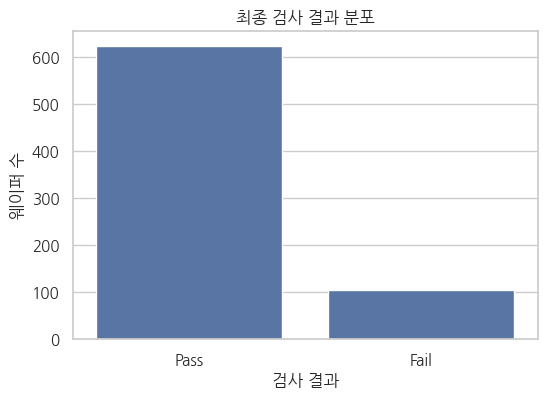

In [ ]:
target_summary = pd.DataFrame({
    '건수': df['inspection_result'].value_counts(),
    '비율(%)': df['inspection_result'].value_counts(normalize=True)
                     .mul(100).round(1)
}).reindex(['Pass', 'Fail'])
display(target_summary)

plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df, x='inspection_result', order=['Pass', 'Fail']
)
ax.set_title('최종 검사 결과 분포')
ax.set_xlabel('검사 결과')
ax.set_ylabel('웨이퍼 수')
plt.show()


**Prompt**

Pass와 Fail의 건수와 비율을 제시하고, 항상 다수 클래스인 Pass로 예측했을 때의 기준 정확도를 포함해 3문장 이내로 해석해 주세요.


**해석:**

`Pass`는 **624건(85.7%)**, `Fail`은 **104건(14.3%)**으로 Pass가 훨씬 많습니다. 항상 Pass로만 예측해도 기준 정확도는 **0.8571**이 됩니다. 따라서 이후 룰은 정확도만 높이는 것이 아니라 실제 Fail을 얼마나 찾는지 보여 주는 Recall과, Fail 예측이 얼마나 정확한지 보여 주는 Precision도 함께 확인해야 합니다.


### 과제 1-5. 식별자 중복과 행별 결측치 분포를 확인하시오.


**Prompt**

현재 `df`에서 `wafer_id`의 고유값 수와 중복 수, 완전히 중복된 행의 수를 확인해 주세요. 수치형 공정 변수에서 각 행의 결측치 수를 계산해 요약 통계와 히스토그램도 출력하는 코드를 작성해 주세요.


,값
전체 행 수,728.00
wafer_id 고유값 수,728.00
wafer_id 중복 수,0.00
완전 중복 행 수,0.00
결측치가 없는 행 수,84.00
결측치가 있는 행 수,644.00
행별 평균 결측치 수,2.22
행별 최대 결측치 수,12.00


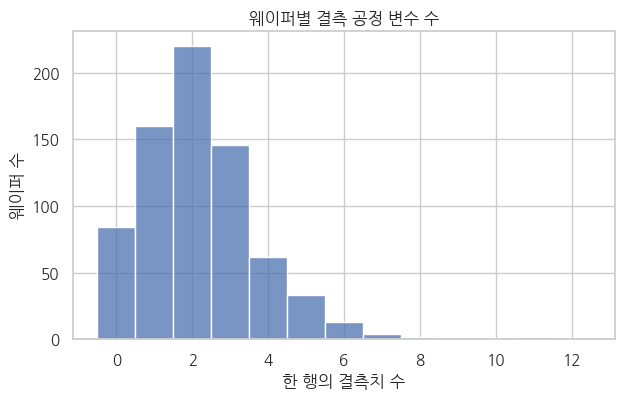

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
row_missing_count = df[numeric_cols].isna().sum(axis=1)

quality_summary = pd.Series({
    '전체 행 수': len(df),
    'wafer_id 고유값 수': df['wafer_id'].nunique(),
    'wafer_id 중복 수': df['wafer_id'].duplicated().sum(),
    '완전 중복 행 수': df.duplicated().sum(),
    '결측치가 없는 행 수': (row_missing_count == 0).sum(),
    '결측치가 있는 행 수': (row_missing_count > 0).sum(),
    '행별 평균 결측치 수': row_missing_count.mean(),
    '행별 최대 결측치 수': row_missing_count.max()
}).round(2)
display(quality_summary.to_frame('값'))

plt.figure(figsize=(7, 4))
ax = sns.histplot(row_missing_count, discrete=True)
ax.set_title('웨이퍼별 결측 공정 변수 수')
ax.set_xlabel('한 행의 결측치 수')
ax.set_ylabel('웨이퍼 수')
plt.show()


**Prompt**

식별자와 중복 여부, 결측치가 있는 행의 수, 행별 평균과 최대 결측치 수를 4문장 이내로 해석해 주세요.


**해석:**

728개의 `wafer_id`가 모두 고유하고 완전히 중복된 행도 없어 각 행을 서로 다른 웨이퍼 기록으로 볼 수 있습니다. 수치형 공정 변수에 결측치가 하나 이상 있는 행은 **644개**, 결측치가 없는 행은 84개입니다. 웨이퍼 한 장당 평균 결측치 수는 **2.22개**이고 최댓값은 12개입니다. 결측치가 일부 행에만 국한되지 않고 넓게 존재하므로 분석 단계마다 사용 가능한 표본 수를 함께 확인해야 합니다.


---
## 2. 시각화 탐색

이제 공정 변수의 분포와 `Pass`·`Fail` 차이를 살펴본다.


### 과제 2-1. 모든 수치형 변수의 분포를 확인하시오. 6행 5열 subplot으로 분석하세요.

**Prompt**

현재 `df`의 모든 수치형 공정 변수를 6행 5열 subplot의 히스토그램으로 한눈에 비교하는 코드를 작성해 주세요. seaborn의 `histplot`을 사용하고 KDE 곡선도 표시하세요. 사용하지 않는 축은 숨겨 주세요.


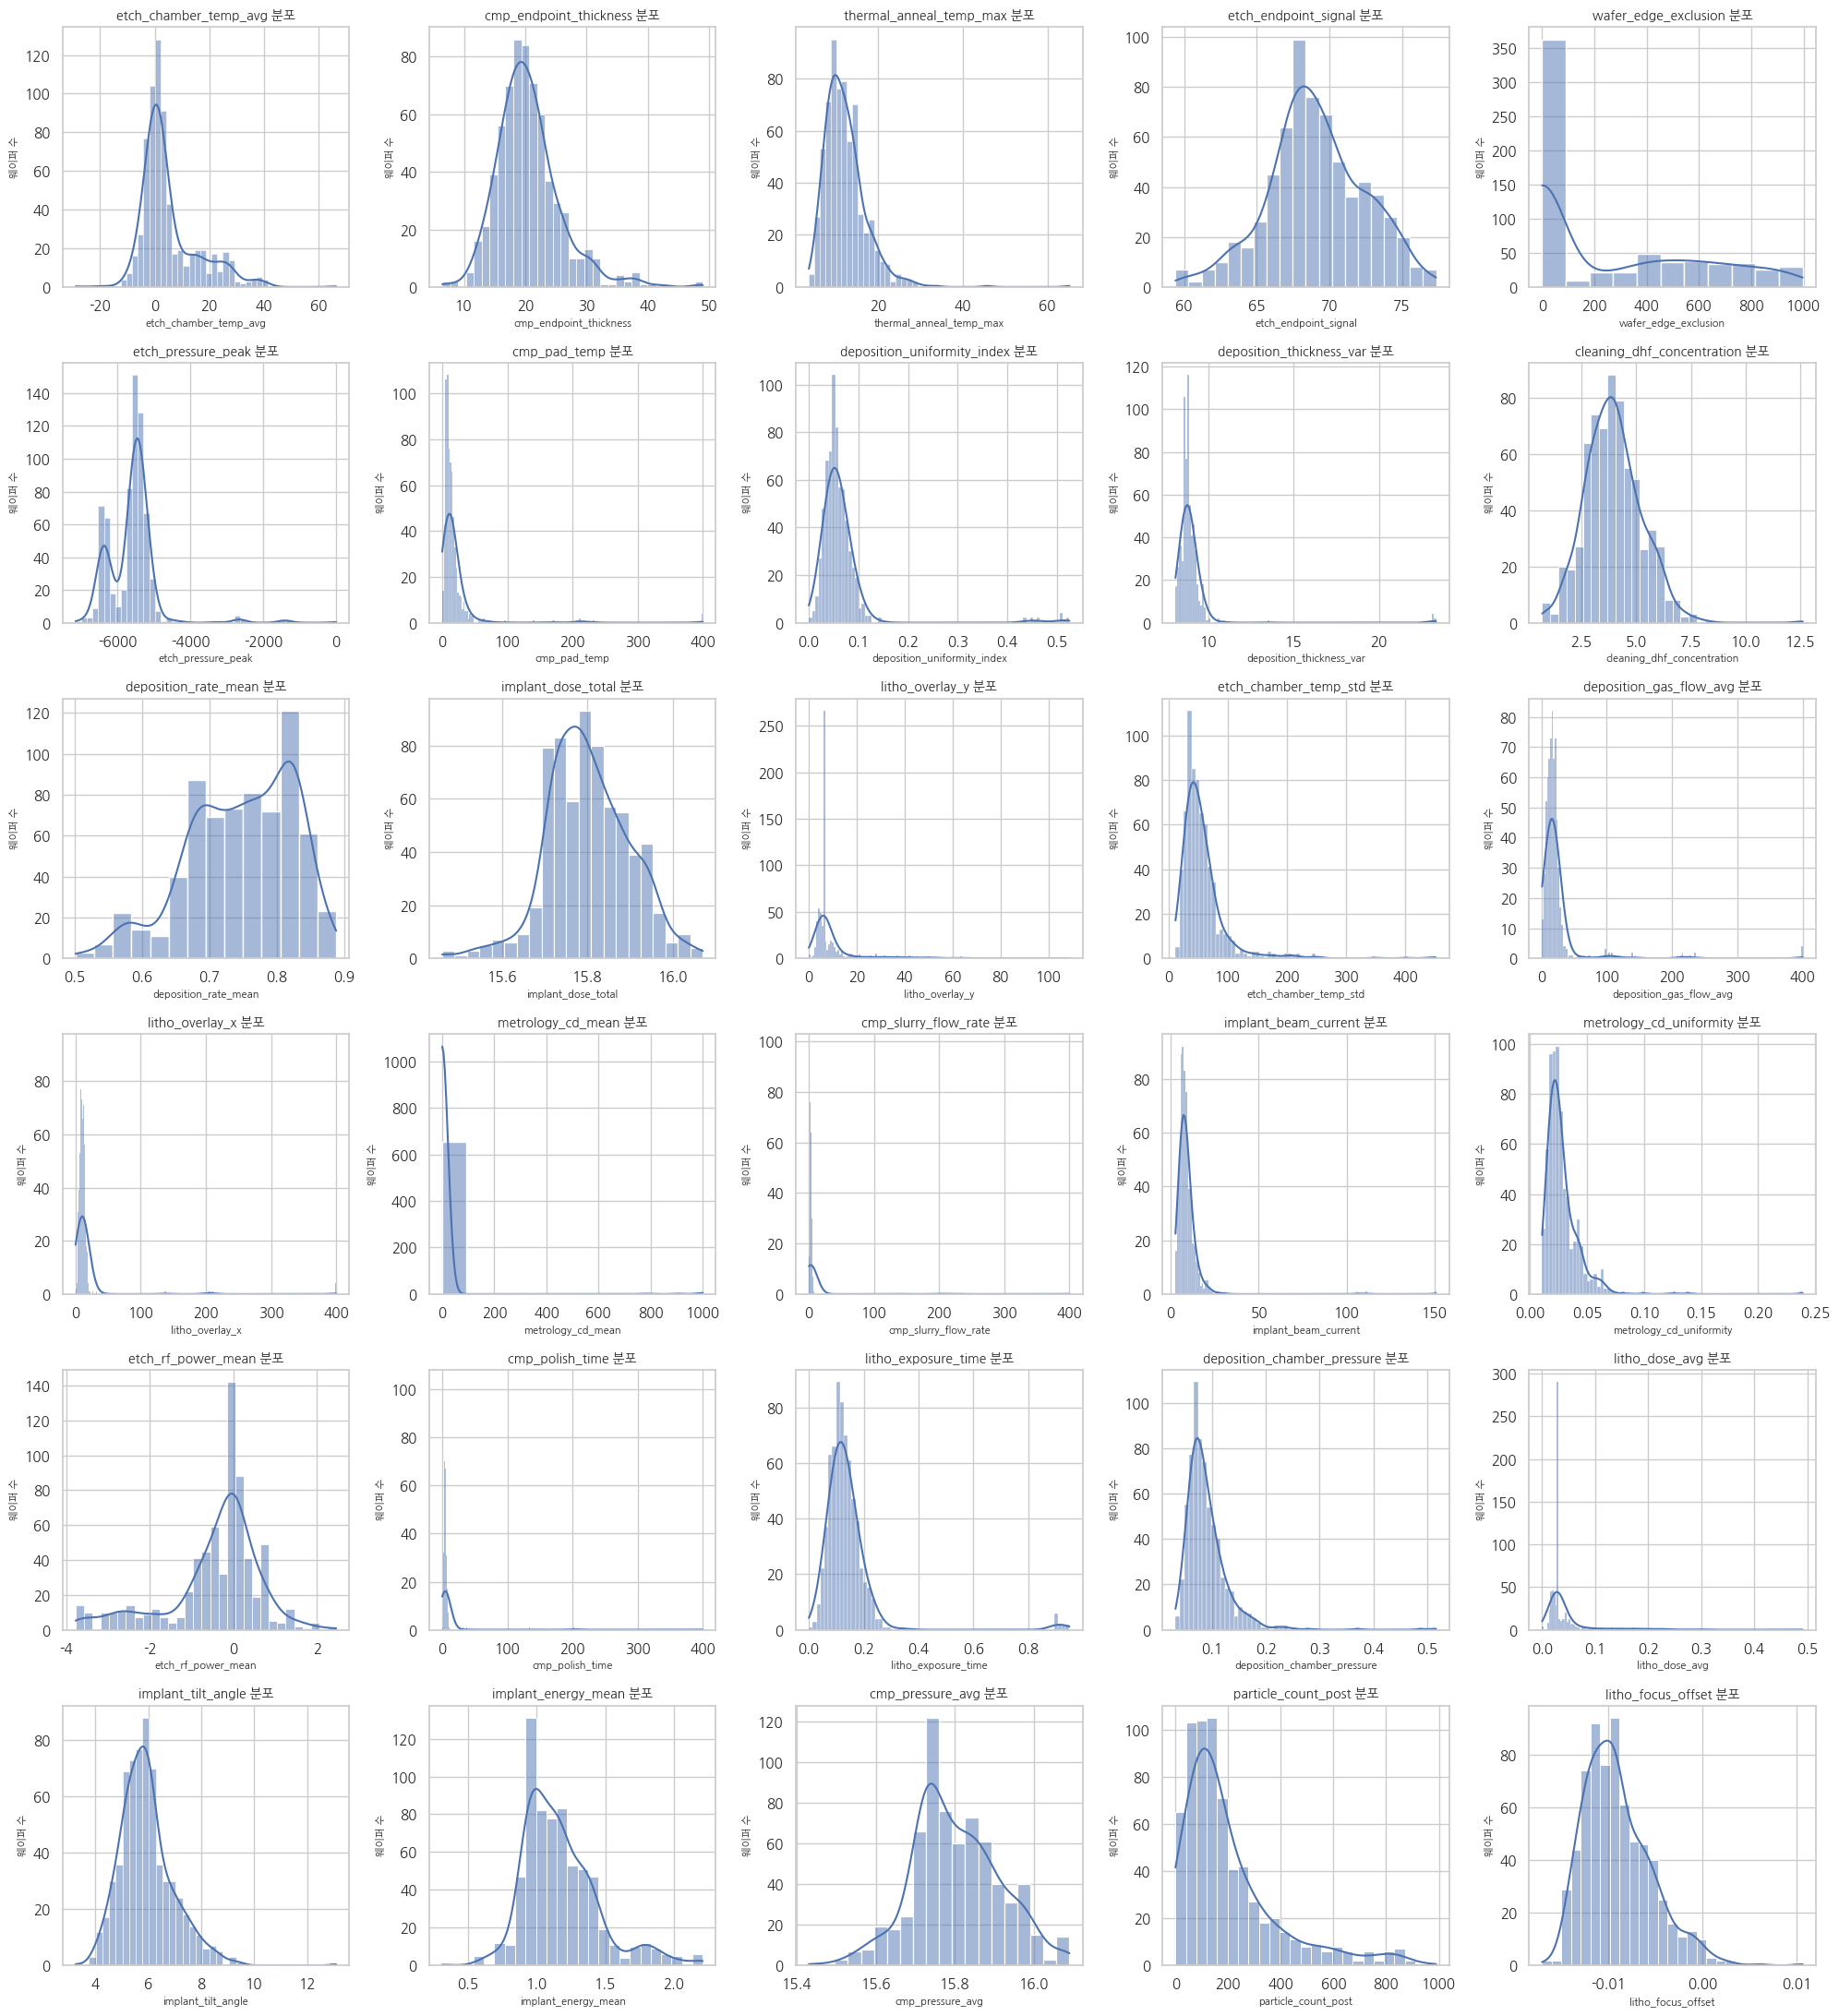

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(6, 5, figsize=(20, 22))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f'{col} 분포', fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('웨이퍼 수', fontsize=8)

for ax in axes.flat[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


**Prompt**

히스토그램을 바탕으로 전체적인 분포 형태와 큰 값이 두드러지는 변수, 비교적 좁은 범위에 모인 변수를 4문장 이내로 해석해 주세요.


**해석:**

여러 공정 변수는 낮은 값에 관측치가 몰리고 큰 값이 드문 오른쪽 꼬리 분포를 보입니다. `metrology_cd_mean`과 일부 CMP·증착·노광 변수에서는 중앙 구간과 멀리 떨어진 큰 값이 나타납니다. 반면 `implant_dose_total`, `cmp_pressure_avg`, `litho_focus_offset` 등은 상대적으로 좁은 범위에 모여 있습니다. 전체 분포만으로는 검사 결과와의 관계를 알 수 없으므로 Pass와 Fail을 나누어 비교해야 합니다.


### 과제 2-2. 모든 수치형 변수의 Pass·Fail별 KDE 분포를 비교하시오.


**Prompt**

현재 `df`의 모든 수치형 공정 변수에 대해 `inspection_result`로 구분한 KDE 곡선을 6행 5열 subplot으로 그리는 코드를 작성해 주세요. `Pass`와 `Fail`을 같은 축에서 비교하고, 두 그룹을 각각 정규화해 분포 모양을 비교할 수 있게 `common_norm=False`를 사용하세요.


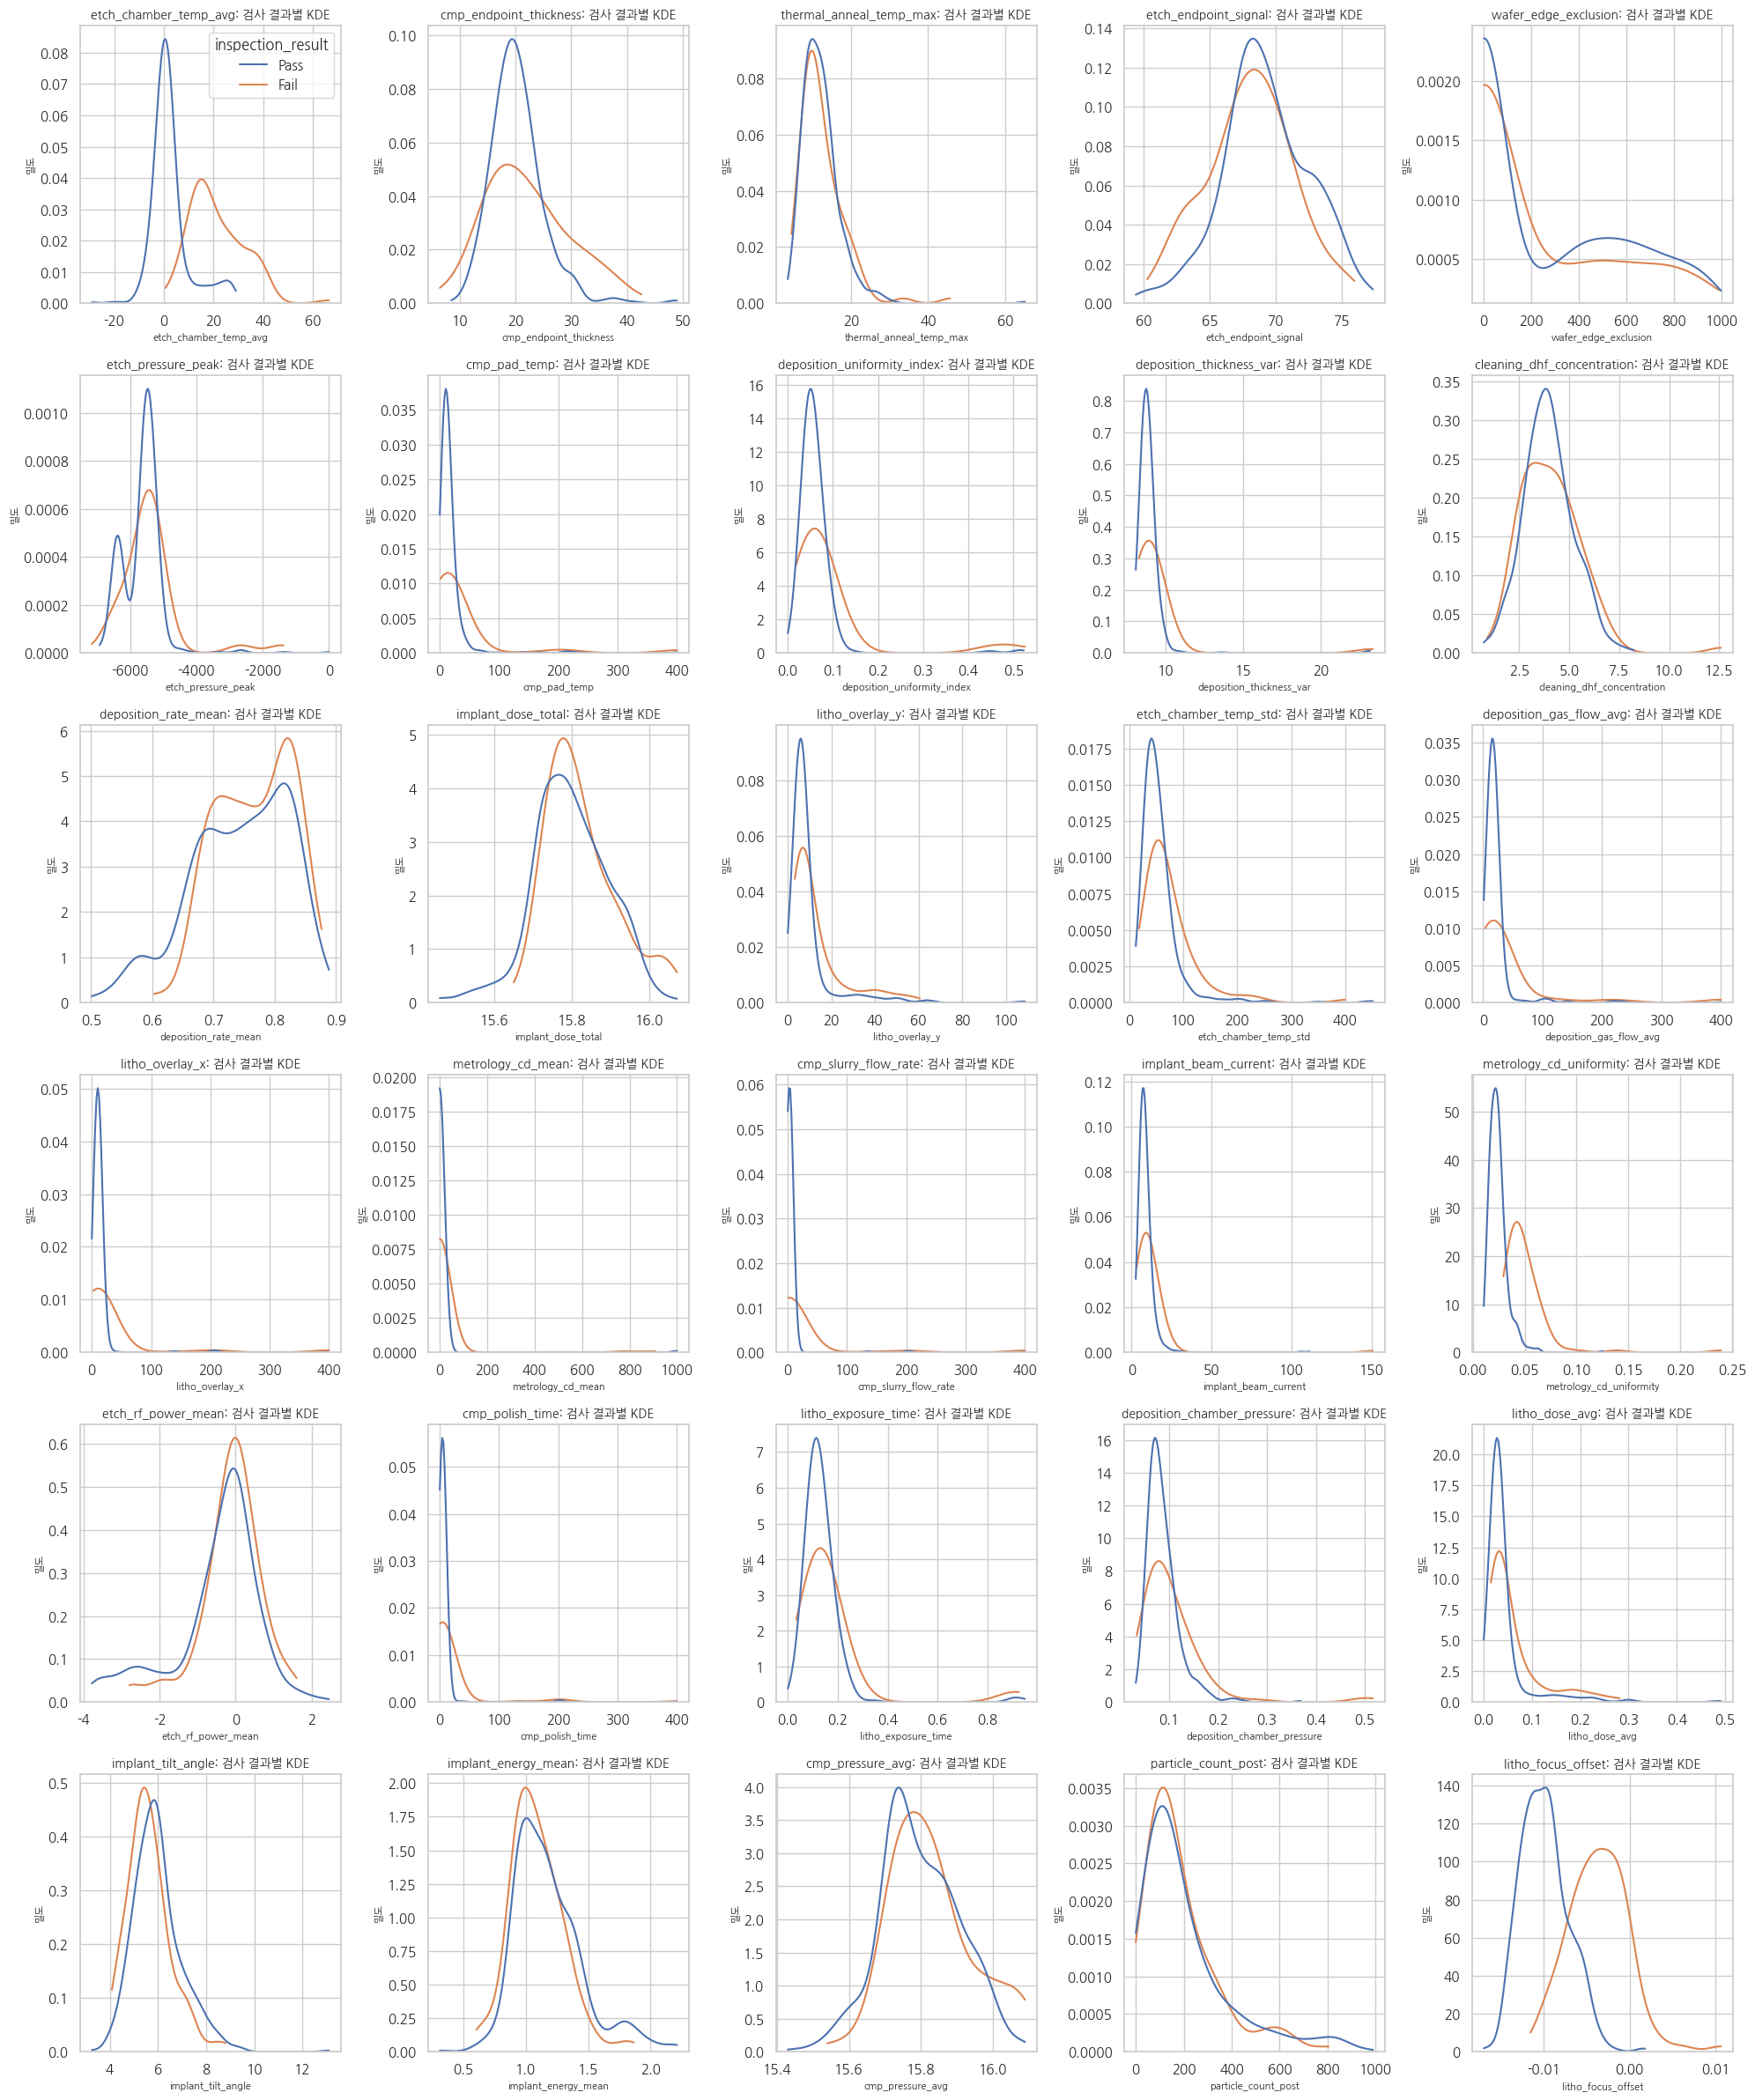

In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(20, 24))
for i, (ax, col) in enumerate(zip(axes.flat, numeric_cols)):
    sns.kdeplot(
        data=df,
        x=col,
        hue='inspection_result',
        hue_order=['Pass', 'Fail'],
        common_norm=False,
        fill=False,
        cut=0,
        warn_singular=False,
        legend=(i == 0),
        ax=ax
    )
    ax.set_title(f'{col}: 검사 결과별 KDE', fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('밀도', fontsize=8)

for ax in axes.flat[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


**추가 Prompt**

방금 직접 실행해 확인한 모든 수치형 변수의 Pass·Fail별 KDE 그래프를 바탕으로, 두 집단의 분포 차이를 박스플롯으로 추가 확인할 변수 6개를 선정해 주세요. 분포 중심의 이동, 두 분포의 겹침 정도, 이상치 일부가 만든 차이인지 여부를 고려하고, 각 변수의 선정 이유와 Fail에서 값이 커지는지 작아지는지를 표로 정리해 주세요. 새로운 계산이나 그래프 작성은 하지 마세요.

**해석:**

Pass와 Fail의 KDE 분포를 비교했을 때 후속 박스플롯으로 확인할 후보 변수는 다음과 같습니다.

| 변수                        | 관찰된 분포 차이                           | Fail에서 나타나는 방향 | 선정 이유                                         |
| ------------------------- | ----------------------------------- | -------------- | --------------------------------------------- |
| `metrology_cd_uniformity` | 두 집단의 분포 중심이 뚜렷하게 다름                | 큰 값 방향         | Pass와 Fail의 겹침이 비교적 적고 Fail 분포가 오른쪽으로 이동함     |
| `etch_chamber_temp_avg`   | Pass는 낮은 값에 집중되고 Fail은 높은 값에 많이 분포함 | 큰 값 방향         | 두 집단의 중심 위치 차이가 크게 나타남                        |
| `litho_focus_offset`      | Fail 분포가 Pass보다 0에 가까운 쪽으로 이동함      | 큰 값 방향         | 두 KDE 곡선의 중심 차이가 비교적 명확함                      |
| `etch_chamber_temp_std`   | Fail 분포가 다소 높은 값 쪽에 위치함             | 큰 값 방향         | 두 집단이 겹치지만 분포 중심과 오른쪽 꼬리에 차이가 보임              |
| `litho_overlay_y`         | Fail에서 높은 값 구간의 비중이 상대적으로 큼         | 큰 값 방향         | 분포가 많이 겹치지만 높은 값 영역에서 차이가 나타남                 |
| `litho_dose_avg`          | Fail 분포가 높은 값 쪽으로 조금 더 퍼져 있음        | 큰 값 방향         | 강한 신호는 아니지만 분포 위치와 오른쪽 꼬리의 차이를 추가로 확인할 가치가 있음 |

`metrology_cd_uniformity`, `etch_chamber_temp_avg`, `litho_focus_offset`은 Pass와 Fail의 분포 차이가 특히 뚜렷한 변수입니다. 나머지 세 변수는 두 집단의 분포가 많이 겹치거나 일부 큰 값의 영향을 받을 가능성이 있어 중간 정도의 후보로 볼 수 있습니다. 이 여섯 변수는 최종 불량 원인이나 룰로 확정한 것이 아니라, 박스플롯과 수치 요약을 통해 분포 중심·이상치·표본 수를 추가로 확인할 대상입니다.


### 과제 2-3. 주요 여섯 변수의 Pass·Fail별 박스플롯을 비교하시오.


**Prompt**

앞선 KDE 그래프 해석에서 선정한 `metrology_cd_uniformity`, `etch_chamber_temp_avg`, `litho_focus_offset`, `etch_chamber_temp_std`, `litho_overlay_y`, `litho_dose_avg`를 signal_cols에 저장해 주세요. 각 변수마다 x축은 inspection_result, y축은 해당 변수인 박스플롯을 2행 3열로 그리는 코드를 작성해 주세요.


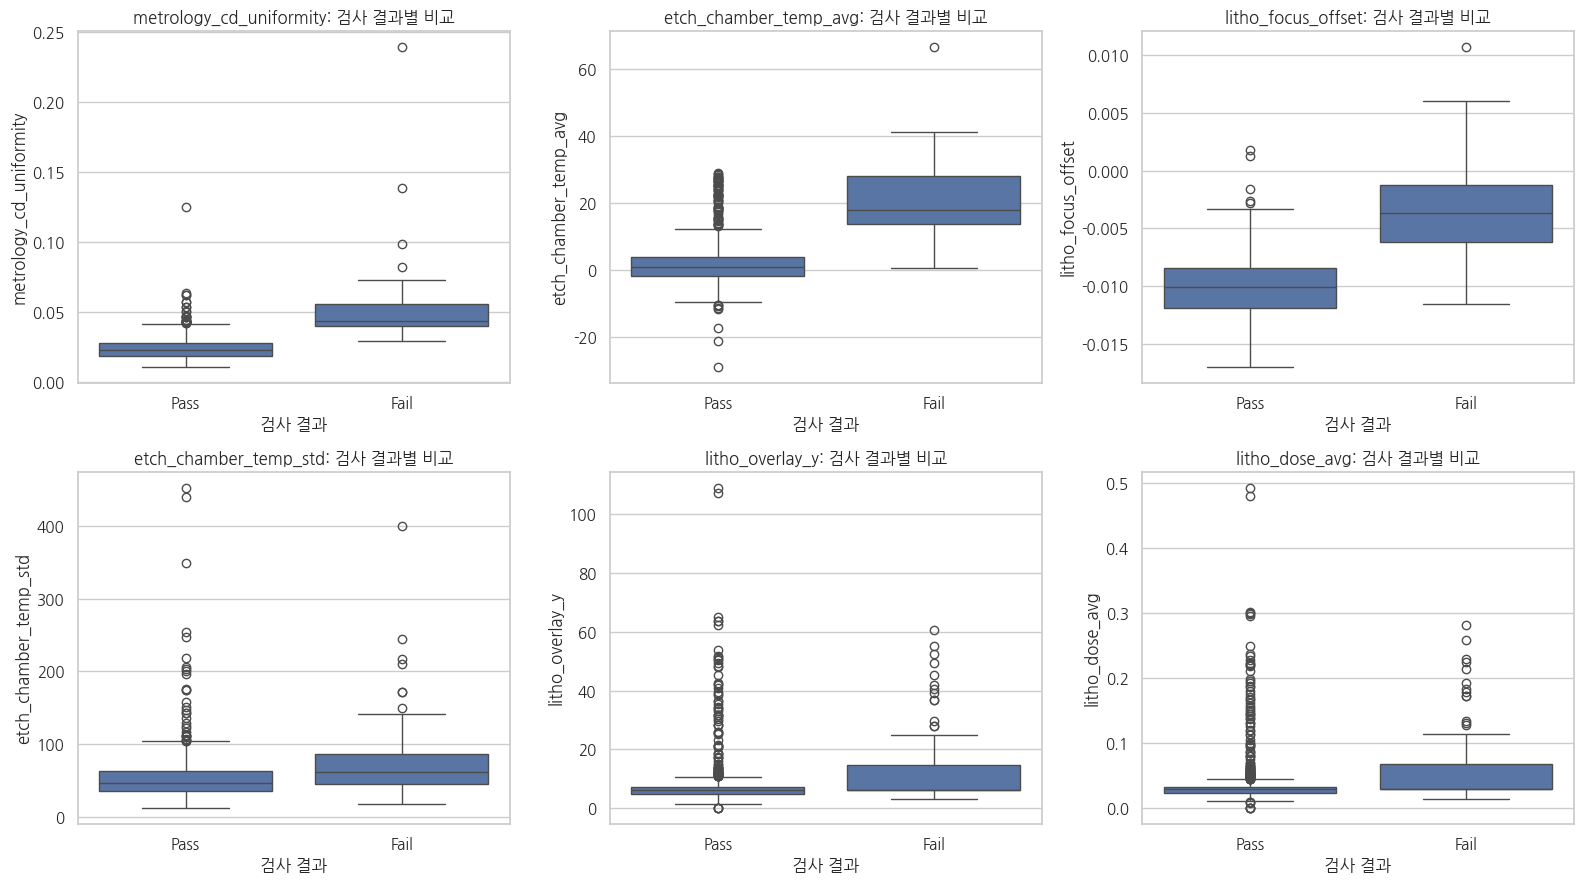

In [ ]:
signal_cols = [
    'metrology_cd_uniformity',
    'etch_chamber_temp_avg',
    'litho_focus_offset',
    'etch_chamber_temp_std',
    'litho_overlay_y',
    'litho_dose_avg'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, signal_cols):
    sns.boxplot(
        data=df,
        x='inspection_result',
        y=col,
        order=['Pass', 'Fail'],
        ax=ax
    )
    ax.set_title(f'{col}: 검사 결과별 비교')
    ax.set_xlabel('검사 결과')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

**Prompt**

박스플롯을 바탕으로 Pass와 Fail의 차이가 뚜렷한 변수와 두 집단이 많이 겹치는 변수를 구분해 주세요. 각 변수의 중앙값 차이와 이상치의 영향을 포함해 4문장 이내로 해석하고, 관찰된 관계를 불량의 원인으로 단정하지 마세요.


**해석:**

`metrology_cd_uniformity` 중앙값은 Pass 0.0229, Fail 0.0436이고, `etch_chamber_temp_avg`는 Pass 0.9518, Fail 17.8968로 두 변수 모두 Fail에서 뚜렷하게 높습니다. `litho_focus_offset`도 Pass -0.0101, Fail -0.0037로 Fail이 0에 가까운 큰 값 쪽에 위치합니다. `etch_chamber_temp_std`는 Pass 46.2492, Fail 61.3699로 차이가 있지만 두 집단의 범위가 많이 겹칩니다. `litho_overlay_y`와 `litho_dose_avg`는 중앙값 차이가 각각 0.0067과 0.0002로 매우 작아, KDE에서 보인 차이는 일부 높은 값과 꼬리 분포의 영향을 받았을 가능성이 있습니다.


### 과제 2-4. 주요 변수의 Pass·Fail별 평균과 중앙값을 표로 비교하시오.


**Prompt**

현재 `df`와 `signal_cols`를 사용해 각 변수의 Pass·Fail별 유효 표본 수, 평균, 중앙값과 `Fail 평균 - Pass 평균`을 하나의 표로 정리하는 코드를 작성해 주세요. 결과는 소수점 넷째 자리까지 표시하세요.


In [ ]:
group_rows = []
for col in signal_cols:
    pass_values = df.loc[df['inspection_result'] == 'Pass', col]
    fail_values = df.loc[df['inspection_result'] == 'Fail', col]
    group_rows.append({
        '변수': col,
        'Pass 유효수': pass_values.notna().sum(),
        'Fail 유효수': fail_values.notna().sum(),
        'Pass 평균': pass_values.mean(),
        'Fail 평균': fail_values.mean(),
        'Pass 중앙값': pass_values.median(),
        'Fail 중앙값': fail_values.median(),
        '평균 차이(Fail-Pass)': fail_values.mean() - pass_values.mean()
    })

group_summary = pd.DataFrame(group_rows).set_index('변수').round(4)
display(group_summary)


,Pass 유효수,Fail 유효수,Pass 평균,Fail 평균,Pass 중앙값,Fail 중앙값,평균 차이(Fail-Pass)
변수,,,,,,,
metrology_cd_uniformity,568,100,0.0243,0.0495,0.0229,0.0436,0.0252
etch_chamber_temp_avg,591,97,2.5491,21.2798,0.9518,17.8968,18.7308
litho_focus_offset,590,101,-0.0099,-0.0036,-0.0101,-0.0037,0.0063
etch_chamber_temp_std,580,95,54.7930,74.7176,46.2492,61.3699,19.9246
litho_overlay_y,564,98,9.3192,12.9162,6.3462,6.3529,3.5970
litho_dose_avg,588,99,0.0426,0.0595,0.0295,0.0297,0.0169


**Prompt**

표본 수 차이와 세 핵심 변수의 평균 차이를 실제 수치로 제시하고, 단위가 다른 변수의 평균 차이를 직접 비교하면 안 되는 이유를 4문장 이내로 해석해 주세요.


**해석:**

결측치 때문에 변수별 유효 표본 수는 다르지만 각 핵심 변수에는 Fail 관측치가 97~101개 남아 있습니다. `metrology_cd_uniformity` 평균은 Pass 0.0243, Fail 0.0495이고 `etch_chamber_temp_avg`는 Pass 2.5491, Fail 21.2798입니다. `litho_focus_offset` 평균은 Pass -0.0099, Fail -0.0036으로 Fail이 더 큰 방향입니다. 변수마다 값의 단위와 범위가 다르므로 원래 단위의 평균 차이 크기를 그대로 비교하기보다 분포 그래프와 타겟 상관관계를 함께 확인해야 합니다.


### 과제 2-5. 각 수치형 변수와 Fail 여부의 상관관계를 확인하시오.


**Prompt**

현재 `df`에 `Fail`이면 1, `Pass`이면 0인 `불량값` 컬럼을 만들고, 모든 수치형 공정 변수와 `불량값`의 상관계수를 절댓값이 큰 순서로 표와 가로 막대그래프로 출력하는 코드를 작성해 주세요.


,Fail 상관계수
etch_chamber_temp_avg,0.6143
litho_focus_offset,0.6129
metrology_cd_uniformity,0.5769
deposition_gas_flow_avg,0.1761
litho_overlay_x,0.1669
cmp_pad_temp,0.1654
deposition_uniformity_index,0.1645
cmp_slurry_flow_rate,0.1629
etch_chamber_temp_std,0.1623
deposition_chamber_pressure,0.1526


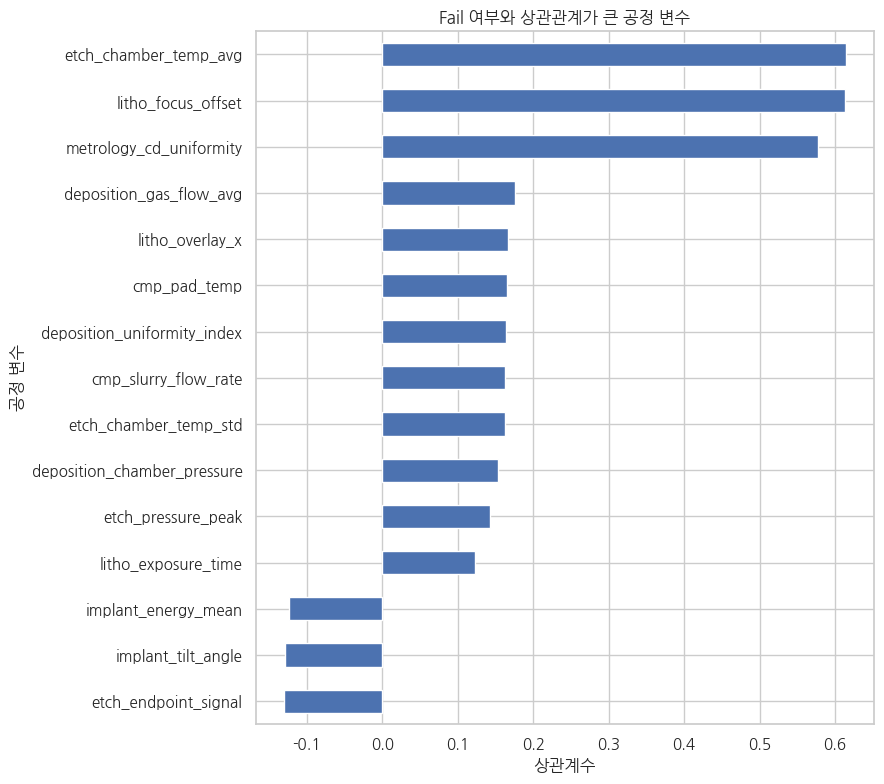

In [ ]:
df['불량값'] = df['inspection_result'].map({'Pass': 0, 'Fail': 1})

feature_cols = [
    col for col in df.select_dtypes(include='number').columns
    if col != '불량값'
]
target_corr = (
    df[feature_cols + ['불량값']]
      .corr()['불량값']
      .drop('불량값')
      .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(target_corr.rename('Fail 상관계수').round(4).to_frame())

plt.figure(figsize=(9, 8))
plot_corr = target_corr.head(15).sort_values()
ax = plot_corr.plot(kind='barh')
ax.set_title('Fail 여부와 상관관계가 큰 공정 변수')
ax.set_xlabel('상관계수')
ax.set_ylabel('공정 변수')
plt.tight_layout()
plt.show()


**Prompt**

Fail 여부와 상관계수 절댓값이 가장 큰 세 변수와 각각의 값을 제시하고, 그다음 변수들과의 차이를 4문장 이내로 해석해 주세요. 상관관계를 인과관계로 표현하지 마세요.


**해석:**

`etch_chamber_temp_avg`의 Fail 상관계수는 **0.6143**, `litho_focus_offset`은 **0.6129**, `metrology_cd_uniformity`는 **0.5769**로 절댓값이 가장 큽니다. 세 변수는 값이 커질수록 Fail이 나타나는 양의 관계를 보입니다. 네 번째 이후 변수의 상관계수 절댓값은 약 0.18 이하로 크게 낮아집니다. 이는 앞의 세 변수가 우선적인 불량 신호 후보라는 뜻이지만 공정 원인으로 확정한다는 의미는 아닙니다.


### 과제 2-6. 주요 변수들의 상관관계를 히트맵으로 확인하시오.


**Prompt**

현재 `df`에서 `불량값`과 `signal_cols`의 상관관계 행렬을 계산하고, 값을 표시한 seaborn 히트맵으로 시각화하는 코드를 작성해 주세요. 색상 범위는 -1부터 1까지로 고정하세요.


,불량값,metrology_cd_uniformity,etch_chamber_temp_avg,litho_focus_offset,etch_chamber_temp_std,litho_overlay_y,litho_dose_avg
불량값,1.0000,0.5769,0.6143,0.6129,0.1623,0.1107,0.1143
metrology_cd_uniformity,0.5769,1.0000,0.4153,0.4541,0.1366,0.1407,0.1808
etch_chamber_temp_avg,0.6143,0.4153,1.0000,0.5671,0.2662,0.2876,0.2936
litho_focus_offset,0.6129,0.4541,0.5671,1.0000,0.5854,0.2164,0.2218
etch_chamber_temp_std,0.1623,0.1366,0.2662,0.5854,1.0000,0.1013,0.1128
litho_overlay_y,0.1107,0.1407,0.2876,0.2164,0.1013,1.0000,0.9996
litho_dose_avg,0.1143,0.1808,0.2936,0.2218,0.1128,0.9996,1.0000


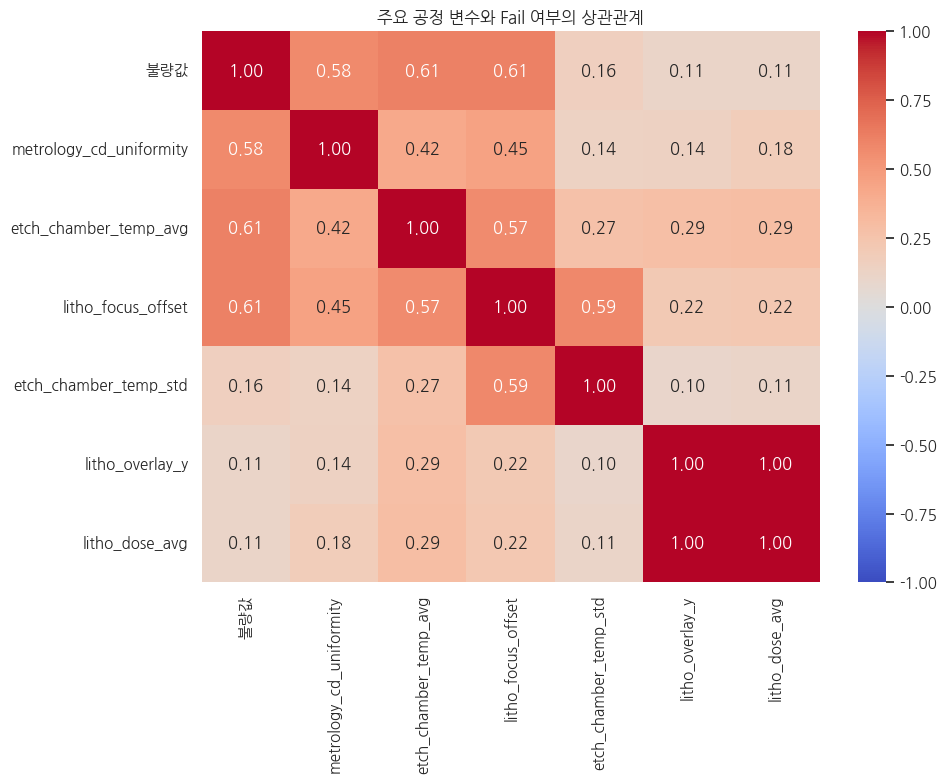

In [ ]:
heatmap_cols = ['불량값'] + signal_cols
signal_corr = df[heatmap_cols].corr().round(4)
display(signal_corr)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    signal_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)
ax.set_title('주요 공정 변수와 Fail 여부의 상관관계')
plt.tight_layout()
plt.show()


**Prompt**

불량값과 주요 변수의 관계뿐 아니라 핵심 변수들끼리의 상관관계도 실제 수치로 비교해 4문장 이내로 해석해 주세요.


**해석:**

불량값은 `etch_chamber_temp_avg`, `litho_focus_offset`, `metrology_cd_uniformity`와 각각 0.6143, 0.6129, 0.5769의 양의 상관관계를 보입니다. `etch_chamber_temp_avg`와 `litho_focus_offset`의 상관계수도 0.5671이고, `metrology_cd_uniformity`는 두 변수와 각각 0.4153, 0.4541의 관계가 있어 세 신호는 완전히 독립적이지 않습니다. 특히 `litho_overlay_y`와 `litho_dose_avg`의 상관계수는 0.9996으로 거의 동일한 정보를 가진 변수에 가깝습니다. 따라서 KDE에서 두 변수가 모두 후보로 선정되더라도 이후 룰을 만들 때는 중복된 정보를 제공하는지 확인해야 합니다.


### 과제 2-7. 세 핵심 변수의 관계를 산점도로 확인하시오.


**Prompt**

현재 `df`에서 `metrology_cd_uniformity`, `etch_chamber_temp_avg`, `litho_focus_offset`의 두 변수 조합 세 개를 1행 3열 산점도로 그려 주세요. `inspection_result`에 따라 색을 다르게 하고, Pass를 먼저 그린 뒤 Fail이 잘 보이게 해 주세요.


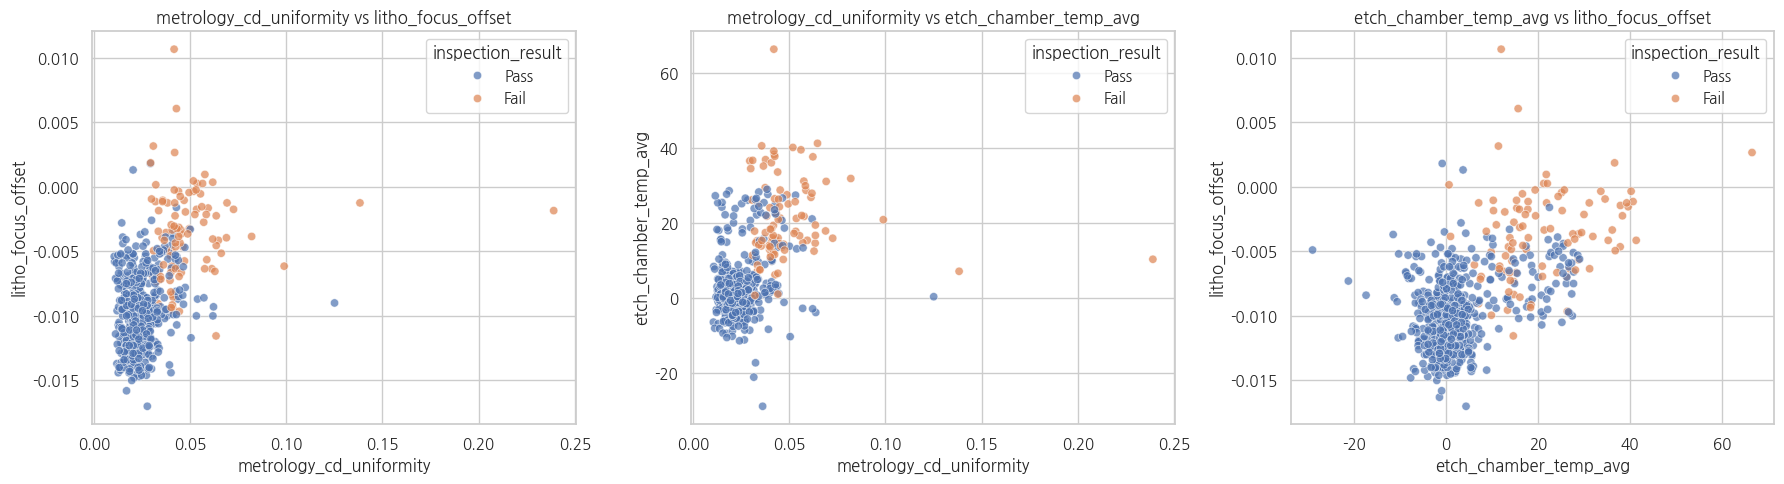

In [ ]:
scatter_pairs = [
    ('metrology_cd_uniformity', 'litho_focus_offset'),
    ('metrology_cd_uniformity', 'etch_chamber_temp_avg'),
    ('etch_chamber_temp_avg', 'litho_focus_offset')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue='inspection_result',
        hue_order=['Pass', 'Fail'],
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f'{x_col} vs {y_col}')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

plt.tight_layout()
plt.show()


**Prompt**

산점도에서 Fail이 주로 모이는 방향과 Pass·Fail이 겹치는 영역을 4문장 이내로 해석해 주세요.


**해석:**

Fail 웨이퍼는 대체로 `metrology_cd_uniformity`, `etch_chamber_temp_avg`, `litho_focus_offset`이 큰 방향에 집중됩니다. 특히 두 변수가 동시에 큰 영역에서는 Fail 점의 비중이 높아집니다. 다만 경계 부근에는 Pass와 Fail이 함께 존재하고 일부 결측치 때문에 모든 웨이퍼가 산점도에 표시되지는 않습니다. 따라서 하나의 직선 경계보다 여러 조건을 조합한 룰을 검증할 필요가 있습니다.


---
## 3. 핵심 변수 심화 분석


### 과제 3-1. `metrology_cd_uniformity`를 0.025, 0.035, 0.040 기준값으로 구간화하고 구간별 불량률을 확인하시오.


**Prompt**

현재 `df`의 `metrology_cd_uniformity`를 `<0.025`, `0.025~<0.035`, `0.035~<0.040`, `>=0.040`으로 구간화해 `CD균일도구간` 컬럼을 만드세요. 구간별 전체 수·불량 수·불량률을 표와 막대그래프로 출력하고, 해당 변수의 결측치 수와 결측치 중 Fail 수를 함께 확인하는 코드를 작성해 주세요.


,전체수,불량수,불량률(%)
CD균일도구간,,,
<0.025,354,0,0.0
0.025~<0.035,178,15,8.4
0.035~<0.040,27,11,40.7
>=0.040,109,74,67.9


결측치 수: 60
결측치 중 Fail 수: 4


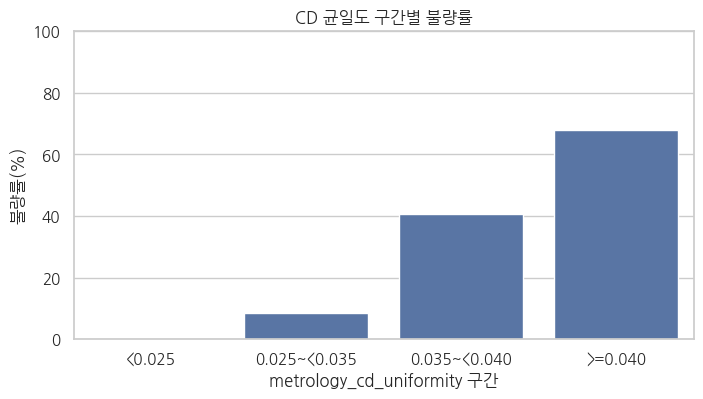

In [ ]:
cd_bins = [-np.inf, 0.025, 0.035, 0.040, np.inf]
cd_labels = ['<0.025', '0.025~<0.035', '0.035~<0.040', '>=0.040']
df['CD균일도구간'] = pd.cut(
    df['metrology_cd_uniformity'],
    bins=cd_bins,
    labels=cd_labels,
    right=False
)

cd_summary = (
    df.groupby('CD균일도구간', observed=False)['불량값']
      .agg(전체수='size', 불량수='sum', 불량률='mean')
)
cd_summary['불량률(%)'] = (cd_summary.pop('불량률') * 100).round(1)
display(cd_summary)
print('결측치 수:', df['metrology_cd_uniformity'].isna().sum())
print(
    '결측치 중 Fail 수:',
    df.loc[df['metrology_cd_uniformity'].isna(), '불량값'].sum()
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=cd_summary.reset_index(),
    x='CD균일도구간',
    y='불량률(%)'
)
ax.set_title('CD 균일도 구간별 불량률')
ax.set_xlabel('metrology_cd_uniformity 구간')
ax.set_ylabel('불량률(%)')
ax.set_ylim(0, 100)
plt.show()


**Prompt**

각 구간의 전체 수와 불량률을 실제 수치로 비교하고 `>=0.040`을 룰 후보로 사용할 수 있는 이유를 4문장 이내로 해석해 주세요.


**해석:**

0.025 미만 구간은 354개 중 Fail이 없고, 0.025 ~ 0.035 미만 구간의 불량률은 8.4%입니다. 0.035 ~ 0.040 미만에서는 27개 중 11개가 Fail로 불량률이 40.7%까지 상승합니다. `metrology_cd_uniformity >= 0.040`에서는 109개 중 74개가 Fail로 불량률이 **67.9%**이므로 표본 수와 불량 집중도가 모두 충분한 룰 후보입니다. 다만 이 변수의 결측치 60개 중에도 Fail 4개가 있어 결측치를 모두 안전한 Pass로 해석해서는 안 됩니다.


### 과제 3-2. `litho_focus_offset`을 -0.008, -0.006, -0.004 기준으로 구간화하고 구간별 불량률을 확인하시오.


**Prompt**

현재 `df`의 `litho_focus_offset`을 `< -0.008`, `-0.008~ < -0.006`, `-0.006~ < -0.004`, `>=-0.004`로 구간화해 `초점오프셋구간` 컬럼을 만드세요. 구간별 전체 수·불량 수·불량률을 표와 막대그래프로 출력하고 결측치 정보도 확인하는 코드를 작성해 주세요.


,전체수,불량수,불량률(%)
초점오프셋구간,,,
<-0.008,466,11,2.4
-0.008~<-0.006,93,18,19.4
-0.006~<-0.004,65,17,26.2
>=-0.004,67,55,82.1


결측치 수: 37
결측치 중 Fail 수: 3


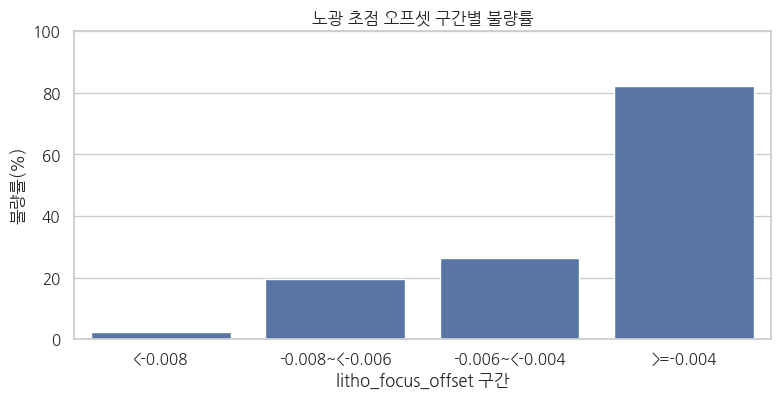

In [ ]:
focus_bins = [-np.inf, -0.008, -0.006, -0.004, np.inf]
focus_labels = [
    '<-0.008', '-0.008~<-0.006',
    '-0.006~<-0.004', '>=-0.004'
]
df['초점오프셋구간'] = pd.cut(
    df['litho_focus_offset'],
    bins=focus_bins,
    labels=focus_labels,
    right=False
)

focus_summary = (
    df.groupby('초점오프셋구간', observed=False)['불량값']
      .agg(전체수='size', 불량수='sum', 불량률='mean')
)
focus_summary['불량률(%)'] = (
    focus_summary.pop('불량률') * 100
).round(1)
display(focus_summary)
print('결측치 수:', df['litho_focus_offset'].isna().sum())
print(
    '결측치 중 Fail 수:',
    df.loc[df['litho_focus_offset'].isna(), '불량값'].sum()
)

plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=focus_summary.reset_index(),
    x='초점오프셋구간',
    y='불량률(%)'
)
ax.set_title('노광 초점 오프셋 구간별 불량률')
ax.set_xlabel('litho_focus_offset 구간')
ax.set_ylabel('불량률(%)')
ax.set_ylim(0, 100)
plt.show()


**Prompt**

각 구간의 불량률 변화와 `>=-0.004` 조건의 표본 수·불량 수를 실제 수치로 비교해 4문장 이내로 해석해 주세요.


**해석:**

-0.008 미만 구간은 466개 중 11개만 Fail로 불량률이 2.4%입니다. 값이 0에 가까워질수록 불량률이 19.4%, 26.2%로 높아지는 흐름이 나타납니다. `litho_focus_offset >= -0.004`에서는 67개 중 55개가 Fail로 불량률이 **82.1%**이며 세부 조건 중 가장 높은 불량 집중도를 보입니다. 결측치 37개 중 Fail은 3개이므로 이 조건도 결측치에 대한 별도 판단은 하지 않습니다.


### 과제 3-3. `etch_chamber_temp_avg`를 0, 5, 10, 20을 기준값으로 구간화하고 구간별 불량률을 확인하시오.


**Prompt**

현재 `df`의 `etch_chamber_temp_avg`를 `<0`, `0~<5`, `5~<10`, `10~<20`, `>=20`으로 구간화해 `식각온도구간` 컬럼을 만드세요. 구간별 전체 수·불량 수·불량률을 표와 막대그래프로 출력하고 결측치 정보도 확인하는 코드를 작성해 주세요.


,전체수,불량수,불량률(%)
식각온도구간,,,
<0,236,0,0.0
0~<5,242,2,0.8
5~<10,52,9,17.3
10~<20,75,42,56.0
>=20,83,44,53.0


결측치 수: 40
결측치 중 Fail 수: 7


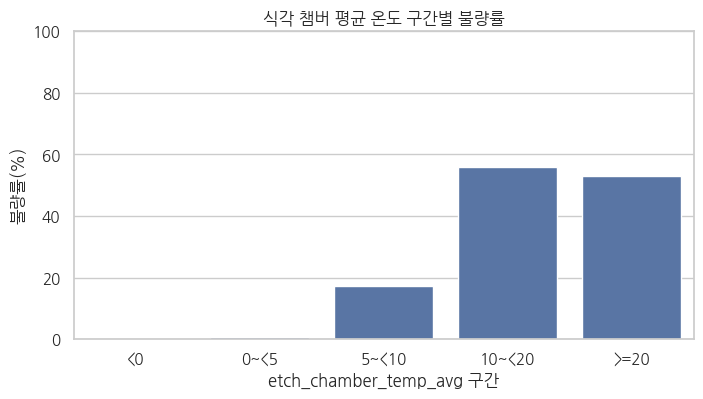

In [ ]:
temp_bins = [-np.inf, 0, 5, 10, 20, np.inf]
temp_labels = ['<0', '0~<5', '5~<10', '10~<20', '>=20']
df['식각온도구간'] = pd.cut(
    df['etch_chamber_temp_avg'],
    bins=temp_bins,
    labels=temp_labels,
    right=False
)

temp_summary = (
    df.groupby('식각온도구간', observed=False)['불량값']
      .agg(전체수='size', 불량수='sum', 불량률='mean')
)
temp_summary['불량률(%)'] = (
    temp_summary.pop('불량률') * 100
).round(1)
display(temp_summary)
print('결측치 수:', df['etch_chamber_temp_avg'].isna().sum())
print(
    '결측치 중 Fail 수:',
    df.loc[df['etch_chamber_temp_avg'].isna(), '불량값'].sum()
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=temp_summary.reset_index(),
    x='식각온도구간',
    y='불량률(%)'
)
ax.set_title('식각 챔버 평균 온도 구간별 불량률')
ax.set_xlabel('etch_chamber_temp_avg 구간')
ax.set_ylabel('불량률(%)')
ax.set_ylim(0, 100)
plt.show()


**Prompt**

10 미만과 10 이상 구간의 불량률을 실제 수치로 비교하고 `>=10` 조건의 장점과 한계를 4문장 이내로 해석해 주세요.


**해석:**

0 미만 구간은 236개 중 Fail이 없고, 0 ~ 5 미만도 242개 중 2개만 Fail입니다. 5~10 미만의 불량률은 17.3%이지만 10 ~ 20 미만은 56.0%, 20 이상은 53.0%로 크게 높아집니다. 두 높은 구간을 묶은 `etch_chamber_temp_avg >= 10` 조건은 158개 중 86개가 Fail로 불량률이 **54.4%**입니다. 비교적 많은 Fail을 찾을 수 있지만 정상 웨이퍼도 72개 포함하므로 다른 강한 룰과 결합할 때 오탐 증가를 확인해야 합니다.


### 과제 3-4. 세 핵심 조건의 위험 신호 수와 불량률을 확인하시오.


**Prompt**

현재 `df`에서 `metrology_cd_uniformity >= 0.040`, `litho_focus_offset >= -0.004`, `etch_chamber_temp_avg >= 10`의 참·거짓을 각각 저장하고, 한 웨이퍼가 만족하는 조건 수를 `위험신호수`로 만드세요. 위험신호수 0~3별 전체 수·불량 수·불량률을 표와 막대그래프로 확인하는 코드를 작성해 주세요. 결측치 비교는 False로 처리하세요.


,전체수,불량수,불량률(%)
위험신호수,,,
0,534,6,1.1
1,94,18,19.1
2,60,43,71.7
3,40,37,92.5


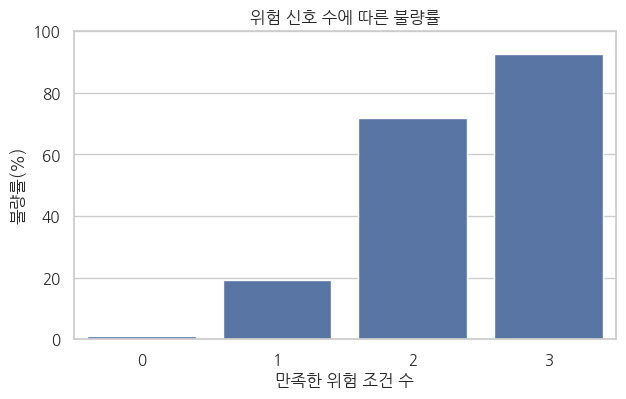

In [ ]:
df['CD균일도위험'] = df['metrology_cd_uniformity'].ge(0.040).fillna(False)
df['초점오프셋위험'] = df['litho_focus_offset'].ge(-0.004).fillna(False)
df['식각온도위험'] = df['etch_chamber_temp_avg'].ge(10).fillna(False)

risk_cols = ['CD균일도위험', '초점오프셋위험', '식각온도위험']
df['위험신호수'] = df[risk_cols].sum(axis=1)

risk_count_summary = (
    df.groupby('위험신호수')['불량값']
      .agg(전체수='size', 불량수='sum', 불량률='mean')
)
risk_count_summary['불량률(%)'] = (
    risk_count_summary.pop('불량률') * 100
).round(1)
display(risk_count_summary)

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=risk_count_summary.reset_index(),
    x='위험신호수',
    y='불량률(%)'
)
ax.set_title('위험 신호 수에 따른 불량률')
ax.set_xlabel('만족한 위험 조건 수')
ax.set_ylabel('불량률(%)')
ax.set_ylim(0, 100)
plt.show()


**Prompt**

위험신호수 0~3별 표본 수와 불량률의 변화를 실제 수치로 비교해 4문장 이내로 해석해 주세요.


**해석:**

위험 신호가 0개인 웨이퍼는 534개이며 불량률은 1.1%에 불과합니다. 신호가 1개이면 94개 중 18개가 Fail로 불량률이 19.1%이고, 2개이면 60개 중 43개가 Fail로 불량률이 71.7%입니다. 세 조건을 모두 만족한 웨이퍼는 40개 중 37개가 Fail로 불량률이 **92.5%**입니다. 위험 신호가 겹칠수록 불량률이 높아지지만 실제 선별 룰은 여러 조건을 AND로 묶을지 OR로 묶을지 목적에 따라 달라집니다.


---
## 4. 핵심 변수에서 불량 룰 만들기

3장에서 구간별 불량률을 확인한 세 변수만 룰 후보로 사용한다. 임계값을 조사하지 않은 다른 변수에는 임의의 판정 기준을 만들지 않는다.


### 과제 4-1. 3장에서 확인한 세 임계값을 불량 룰 후보로 만들고 비교하시오.

- `rule1`: `metrology_cd_uniformity >= 0.040`
- `rule2`: `litho_focus_offset >= -0.004`
- `rule3`: `etch_chamber_temp_avg >= 10`


**Prompt**

현재 `df`에서 3장의 구간별 불량률 분석으로 확인한 다음 세 조건을 각각 하나의 불량 룰 후보로 만드세요.

- `rule1`: `metrology_cd_uniformity >= 0.040`
- `rule2`: `litho_focus_offset >= -0.004`
- `rule3`: `etch_chamber_temp_avg >= 10`

각 조건을 만족하는 웨이퍼 수, 실제 Fail 수, 실제 Pass 수, 불량률, 전체 불량률보다 몇 %p 높은지를 하나의 표로 비교하는 코드를 작성해 주세요. 이후 과제에서도 사용할 수 있도록 각 조건의 참·거짓 결과를 `rule1`, `rule2`, `rule3`에 저장하고 결측치 비교는 False로 처리하세요.


In [ ]:
overall_fail_rate = df['불량값'].mean() * 100
print(f'전체 불량률: {overall_fail_rate:.1f}%')

rule1 = (
    df['metrology_cd_uniformity'].notna()
    & (df['metrology_cd_uniformity'] >= 0.040)
)
rule2 = (
    df['litho_focus_offset'].notna()
    & (df['litho_focus_offset'] >= -0.004)
)
rule3 = (
    df['etch_chamber_temp_avg'].notna()
    & (df['etch_chamber_temp_avg'] >= 10)
)

candidate_conditions = [
    ('rule1', 'metrology_cd_uniformity >= 0.040', rule1),
    ('rule2', 'litho_focus_offset >= -0.004', rule2),
    ('rule3', 'etch_chamber_temp_avg >= 10', rule3)
]

candidate_rows = []
for rule_name, condition_name, condition in candidate_conditions:
    condition_count = int(condition.sum())
    fail_count = int(df.loc[condition, '불량값'].sum())
    pass_count = condition_count - fail_count
    fail_rate = fail_count / condition_count * 100

    candidate_rows.append({
        '룰': rule_name,
        '조건': condition_name,
        '조건 만족 수': condition_count,
        'Fail 수': fail_count,
        'Pass 수': pass_count,
        '불량률(%)': fail_rate,
        '전체 대비(%p)': fail_rate - overall_fail_rate
    })

candidate_table = pd.DataFrame(candidate_rows)
display(candidate_table.round(1))


전체 불량률: 14.3%


,룰,조건,조건 만족 수,Fail 수,Pass 수,불량률(%),전체 대비(%p)
0,rule1,metrology_cd_uniformity >= 0.040,109,74,35,67.9,53.6
1,rule2,litho_focus_offset >= -0.004,67,55,12,82.1,67.8
2,rule3,etch_chamber_temp_avg >= 10,158,86,72,54.4,40.1


**Prompt**

세 룰 후보의 조건 만족 수, 실제 Fail·Pass 수, 불량률, 전체 불량률과의 차이를 실제 수치로 비교해 주세요. 각 룰이 정밀한 불량 선별과 넓은 불량 포착 중 어느 쪽에 더 적합해 보이는지도 포함하여 4문장 이내로 해석해 주세요.


**해석:**

전체 불량률은 14.3%이며, rule1은 109개 중 Fail 74개·Pass 35개로 불량률이 67.9%여서 전체보다 53.6%p 높습니다. rule2는 67개 중 Fail 55개·Pass 12개로 불량률이 82.1%이며 세 후보 중 불량 집중도가 가장 높습니다. rule3는 158개 중 Fail 86개·Pass 72개로 불량률은 54.4%이므로 가장 넓은 범위를 포착하지만 정상 웨이퍼도 많이 포함합니다. 따라서 rule1은 균형적인 출발점, rule2는 정밀한 추가 선별, rule3는 재현율 확대 후보로 보고 실제 예측 성능과 중복을 검증해야 합니다.


### 과제 4-2. 세 룰의 검증 순서를 정하시오.


**Prompt**

앞의 구간별 불량률과 세 룰 후보 비교 결과를 바탕으로 `rule1`을 먼저 검증하고, 여기에 `rule2`, `rule3`을 차례로 OR 조건으로 추가하는 검증 계획을 세워 주세요. 각 룰의 조건, 조건 만족 수, Fail 수, 불량률, 배치 이유를 표로 정리하고, 개별 불량률만으로 최종 룰을 결정할 수 없는 이유를 4문장 이내로 설명해 주세요.


**검증 계획:**

| 순서 | 룰 | 조건 | 조건 만족 수 | Fail 수 | 불량률 | 배치 이유 |
|---:|---|---|---:|---:|---:|---|
| 1 | rule1 | `metrology_cd_uniformity >= 0.040` | 109 | 74 | 67.9% | 표본 수와 불량 집중도가 모두 충분한 출발점 |
| 2 | rule2 | `litho_focus_offset >= -0.004` | 67 | 55 | 82.1% | rule1이 놓친 Fail을 적은 오탐으로 보완하는지 확인 |
| 3 | rule3 | `etch_chamber_temp_avg >= 10` | 158 | 86 | 54.4% | 넓은 Fail 포착 범위가 재현율과 오탐에 미치는 영향 확인 |

rule1은 표본 수와 불량률의 균형이 좋아 첫 번째 기준으로 사용합니다. rule2는 불량률이 가장 높지만 rule1과 같은 웨이퍼를 주로 찾는다면 결합 효과가 작을 수 있으므로 두 번째로 추가합니다. rule3는 Fail을 넓게 포함하는 대신 Pass도 72개 포함하므로 마지막에 추가하여 재현율 증가와 오탐 증가를 함께 확인합니다. 따라서 최종 룰은 각 조건의 개별 불량률이 아니라 중복을 제외한 추가 기여와 정확도·정밀도·재현율·F1의 변화를 보고 선택해야 합니다.


---
## 5. 불량 룰 성능 검증과 최종 선택


### 과제 5-1. 세 불량 룰의 개별 성능을 검증하시오.


**Prompt**

3장에서 임계값을 확인하고 4장에서 비교한 세 조건을 각각 `rule1`, `rule2`, `rule3`으로 정의해 주세요. 각 조건을 만족하면 Fail, 아니면 Pass로 예측하고, 모든 웨이퍼를 Pass로 예측하는 베이스라인과 각 개별 룰의 Fail 예측 수·정확도·정밀도·재현율·F1을 하나의 표로 비교하는 코드를 작성해 주세요. 결측치 비교는 False로 처리하세요.


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

y_true = df['불량값']
baseline = pd.Series(False, index=df.index)

rule1 = (
    df['metrology_cd_uniformity'].notna()
    & (df['metrology_cd_uniformity'] >= 0.040)
)
rule2 = (
    df['litho_focus_offset'].notna()
    & (df['litho_focus_offset'] >= -0.004)
)
rule3 = (
    df['etch_chamber_temp_avg'].notna()
    & (df['etch_chamber_temp_avg'] >= 10)
)

rule_predictions = {
    '베이스라인: 모두 Pass': baseline,
    '룰1: CD 균일도 >= 0.040': rule1,
    '룰2: 초점 오프셋 >= -0.004': rule2,
    '룰3: 식각 온도 평균 >= 10': rule3
}

individual_rows = []
for name, pred in rule_predictions.items():
    individual_rows.append({
        '모델': name,
        'Fail 예측 수': int(pred.sum()),
        '정확도': accuracy_score(y_true, pred),
        '정밀도': precision_score(y_true, pred, zero_division=0),
        '재현율': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0)
    })

individual_results = pd.DataFrame(individual_rows)
metric_cols = ['정확도', '정밀도', '재현율', 'F1']
individual_results[metric_cols] = (
    individual_results[metric_cols].round(4)
)
display(individual_results)


,모델,Fail 예측 수,정확도,정밀도,재현율,F1
0,베이스라인: 모두 Pass,0,0.8571,0.0000,0.0000,0.0000
1,룰1: CD 균일도 >= 0.040,109,0.9107,0.6789,0.7115,0.6948
2,룰2: 초점 오프셋 >= -0.004,67,0.9162,0.8209,0.5288,0.6433
3,룰3: 식각 온도 평균 >= 10,158,0.8764,0.5443,0.8269,0.6565


**Prompt**

베이스라인과 세 개별 룰의 정확도·정밀도·재현율·F1을 실제 수치로 비교하고 각 룰의 장단점을 4문장 이내로 해석해 주세요.


**해석:**

모두 Pass로 예측하는 베이스라인의 정확도는 **0.8571**이지만 Fail을 전혀 찾지 못해 재현율과 F1은 0입니다. rule1은 정확도 0.9107, 정밀도 0.6789, 재현율 0.7115, F1 0.6948로 균형이 비교적 좋습니다. rule2는 정밀도가 0.8209로 가장 높지만 재현율은 0.5288이고, rule3는 재현율이 0.8269로 가장 높지만 정밀도는 0.5443입니다. 따라서 rule1을 시작점으로 rule2와 rule3을 추가했을 때 실제 Fail과 Pass가 각각 얼마나 새로 포함되는지 확인해야 합니다.


### 과제 5-2. 세 룰을 단계적으로 OR 결합하고 추가 기여를 검증하시오.


**Prompt**

검증 계획에 따라 `rule1`, `rule2`, `rule3`을 OR 조건으로 단계적으로 결합해 `rule12`, `rule123`을 만들어 주세요. 각 룰을 추가할 때 후보 조건 인원, 기존 룰과 중복되는 인원, 새롭게 Fail로 예측되는 인원, 그중 실제 Fail과 Pass 수를 계산하세요. `rule1`, `rule1+2`, `rule1+2+3`의 정확도·정밀도·재현율·F1과 혼동행렬의 TN·FP·FN·TP도 하나의 표로 비교하는 코드를 작성해 주세요.


In [ ]:
from sklearn.metrics import confusion_matrix

rule12 = rule1 | rule2
rule123 = rule1 | rule2 | rule3

addition_steps = [
    ('룰1: CD 균일도', baseline, rule1),
    ('룰2: 초점 오프셋 추가', rule1, rule2),
    ('룰3: 식각 온도 추가', rule12, rule3)
]

contribution_rows = []
for name, previous_rule, added_rule in addition_steps:
    overlap = previous_rule & added_rule
    newly_predicted = added_rule & ~previous_rule

    contribution_rows.append({
        '추가 단계': name,
        '후보 조건 인원': int(added_rule.sum()),
        '기존 룰과 중복': int(overlap.sum()),
        '새 Fail 예측': int(newly_predicted.sum()),
        '새 예측 중 실제 Fail': int((y_true[newly_predicted] == 1).sum()),
        '새 예측 중 실제 Pass': int((y_true[newly_predicted] == 0).sum())
    })

rule_contribution = pd.DataFrame(contribution_rows)
display(rule_contribution)

combined_predictions = {
    '룰1': rule1,
    '룰1+2': rule12,
    '룰1+2+3': rule123
}

combined_rows = []
for name, pred in combined_predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    combined_rows.append({
        '모델': name,
        '정확도': accuracy_score(y_true, pred),
        '정밀도': precision_score(y_true, pred, zero_division=0),
        '재현율': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

combined_results = pd.DataFrame(combined_rows)
combined_results[metric_cols] = combined_results[metric_cols].round(4)
display(combined_results)


,추가 단계,후보 조건 인원,기존 룰과 중복,새 Fail 예측,새 예측 중 실제 Fail,새 예측 중 실제 Pass
0,룰1: CD 균일도,109,0,109,74,35
1,룰2: 초점 오프셋 추가,67,46,21,13,8
2,룰3: 식각 온도 추가,158,94,64,11,53


,모델,정확도,정밀도,재현율,F1,TN,FP,FN,TP
0,룰1,0.9107,0.6789,0.7115,0.6948,589,35,30,74
1,룰1+2,0.9176,0.6692,0.8365,0.7436,581,43,17,87
2,룰1+2+3,0.8599,0.5052,0.9423,0.6577,528,96,6,98


**Prompt**

룰을 추가할 때 중복 인원과 새로 추가되는 실제 Fail·Pass 수를 확인하고, 정확도·정밀도·재현율·F1과 오탐·미탐이 어떻게 변하는지 실제 수치로 비교해 4문장 이내로 해석해 주세요. 최종 룰에서 제외할 조건도 판단해 주세요.


**해석:**

rule1은 109개를 Fail로 예측해 실제 Fail 74개와 Pass 35개를 포함하며 정확도 0.9107, F1 0.6948을 기록합니다. rule2는 rule1과 46개가 중복되고 새로 추가한 21개 중 Fail 13개·Pass 8개를 찾아 정확도는 0.9176, 재현율은 0.8365, F1은 0.7436으로 높아집니다. rule3는 기존 룰과 94개가 중복되고 새로 추가한 64개 중 실제 Fail은 11개뿐이며 Pass가 53개라서 재현율은 0.9423으로 오르지만 정확도와 F1은 0.8599와 0.6577로 낮아집니다. 따라서 rule3는 최종 룰에서 제외하고 `rule1 OR rule2`를 선택하는 편이 균형적입니다.


### 과제 5-3. 성능 변화를 바탕으로 최종 룰을 선택하고 평가하시오.


**Prompt**

앞서 확인한 세 룰의 단계별 성능과 추가 기여를 바탕으로 최종 룰을 선택해 주세요. 재현율을 높이더라도 정확도·정밀도·F1을 지나치게 낮추는 룰은 제외하고, 선택한 최종 룰의 혼동행렬을 seaborn 히트맵으로 시각화한 뒤 `Pass`와 `Fail`의 분류 리포트를 출력하는 코드를 작성해 주세요.


선택한 최종 룰: metrology_cd_uniformity >= 0.040 OR litho_focus_offset >= -0.004


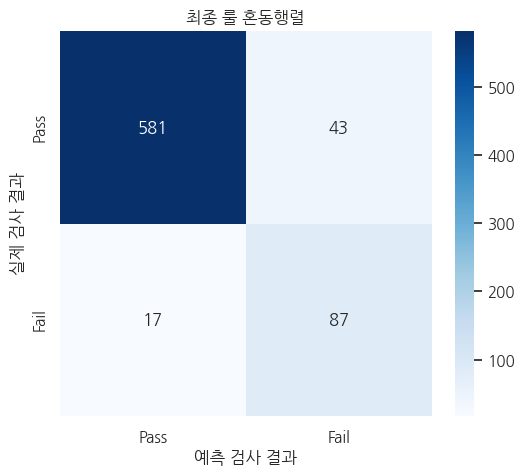

              precision    recall  f1-score   support

        Pass     0.9716    0.9311    0.9509       624
        Fail     0.6692    0.8365    0.7436       104

    accuracy                         0.9176       728
   macro avg     0.8204    0.8838    0.8472       728
weighted avg     0.9284    0.9176    0.9213       728



In [ ]:
from sklearn.metrics import classification_report

final_rule_name = (
    'metrology_cd_uniformity >= 0.040 OR '
    'litho_focus_offset >= -0.004'
)
final_rule = rule12
print('선택한 최종 룰:', final_rule_name)

cm_rule = confusion_matrix(y_true, final_rule)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_rule,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pass', 'Fail'],
    yticklabels=['Pass', 'Fail']
)
ax.set_title('최종 룰 혼동행렬')
ax.set_xlabel('예측 검사 결과')
ax.set_ylabel('실제 검사 결과')
plt.show()

print(classification_report(
    y_true,
    final_rule,
    target_names=['Pass', 'Fail'],
    digits=4
))


**Prompt**

혼동행렬의 네 수치와 Pass·Fail 클래스별 지표를 바탕으로 최종 룰의 활용 범위와 한계를 4문장 이내로 해석해 주세요.


**해석:**

최종 룰은 실제 Pass 624개 중 581개를 Pass로 맞혔고 43개를 Fail로 잘못 예측했습니다. 실제 Fail 104개 중 87개를 찾아냈고 17개를 놓쳐 Fail 클래스의 정밀도는 0.6692, 재현율은 0.8365, F1은 0.7436입니다. Pass 클래스의 정밀도는 0.9716, 재현율은 0.9311로 Fail 클래스보다 높습니다. 두 개의 이해하기 쉬운 조건으로 불량 위험 웨이퍼를 1차 선별하는 데는 유용하지만 오탐 43개와 미탐 17개가 남아 있으므로 최종 품질 판정을 대신할 수는 없습니다.
